### Cuaderno 14 adaptado: ablacion tamano vs contexto --- CLIP-B, CLIP-L y LongCLIP sobre graficos del Financiero

**Proyecto**: evaluacion responsable de modelos multimodales en supervision bancaria (MCC225, Actividad 5).

**Pregunta de la v3**: la auditoria de truncacion mostro que los resumenes (caption_3/4) exceden el limite de 77 tokens de CLIP. ¿Que pasa cuando el texto entra completo al encoder? LongCLIP (248 tokens) responde eso, pero como es un ViT-Large, se incluye **CLIP-L como control de tamano** para separar los dos factores:

```
CLIP-B/77  ->  CLIP-L/77      : solo cambia el tamano   -> efecto tamano
CLIP-L/77  ->  LongCLIP-L/248 : solo cambia el contexto -> efecto contexto
```

**Captions**: caption_2 (titulo), caption_3 (resumen con plantilla), caption_4 (resumen limpio).

**Diseño**: 3 modelos x 3 captions = 9 experimentos + 3 baselines desplazados.

**Requisitos**: junto a `manifest_local2.csv` (con caption_4) e `images/`. GPU recomendada (~5 GB VRAM); en CPU funciona pero tarda mas.

In [1]:
# En Colab: descomentar y ajustar
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/sbs_iesf_pares
%cd /tf/work/prac/sbs_iesf_pares

/tf/work/prac/sbs_iesf_pares


In [2]:
# transformers fijado <5 (cambio de API en v5); safetensors por CVE-2025-32434 en torch<2.6
%pip install -q "transformers>=4.49,<5" safetensors torch torchvision pillow pandas numpy matplotlib tqdm

^C
ERROR: Operation cancelled by user

[notice] A new release of pip is available: 23.3.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json, random, shutil, sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 22514
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH = 8
CAPTIONS = ["caption_2", "caption_3", "caption_4"]

MODEL_SPECS = {
    "CLIP":     {"name": "openai/clip-vit-base-patch32",  "longclip": False, "maxlen": 77},
    "CLIP-L":   {"name": "openai/clip-vit-large-patch14", "longclip": False, "maxlen": 77},
    "LongCLIP": {"name": "zer0int/LongCLIP-GmP-ViT-L-14", "longclip": True,  "maxlen": 248},
}

ROOT = Path(".").resolve()
RESULTS = ROOT / "results"; FIGURES = ROOT / "figures"; FIG_CASOS = FIGURES / "casos"
for d in [RESULTS, FIGURES, FIG_CASOS]: d.mkdir(parents=True, exist_ok=True)
print(f"Dispositivo: {DEVICE} | torch {torch.__version__} | modelos: {list(MODEL_SPECS)}")

/tf/work/torch_gpu_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cuda | torch 2.5.1+cu121 | modelos: ['CLIP', 'CLIP-L', 'LongCLIP']


In [3]:
manifest = pd.read_csv("manifest_local2.csv")
assert {"image_path", *CAPTIONS}.issubset(manifest.columns), f"Faltan columnas; se requieren {CAPTIONS}"
missing = [p for p in manifest["image_path"] if not Path(p).exists()]
print(f"Pares: {len(manifest)} | Imagenes faltantes: {len(missing)}")
assert not missing, f"Rutas rotas: {missing[:3]}"
manifest.head(3)

Pares: 40 | Imagenes faltantes: 0


,image_id,image_path,caption_1,caption_2,caption_3,caption_4,chart_id,source_page_pdf,source_report
0,img_000,images/grafico_000_I_1.png,Grafico I.1: Mapa de vulnerabilidades del sist...,Mapa de vulnerabilidades del sistema financier...,El grafico muestra mapa de vulnerabilidades de...,Mapa de vulnerabilidades del sistema financier...,I.1,15,SBS - Informe de Estabilidad del Sistema Finan...
1,img_001,images/grafico_001_II_1.png,Grafico II.1: Crecimiento economico mundial (V...,Crecimiento economico mundial (Variacion porce...,El grafico muestra crecimiento economico mundi...,Crecimiento economico mundial (variacion porce...,II.1,21,SBS - Informe de Estabilidad del Sistema Finan...
2,img_002,images/grafico_002_II_2.png,Grafico II.2: Inflacion global promedio de per...,Inflacion global promedio de periodo (Porcenta...,El grafico muestra inflacion global promedio d...,Inflacion global promedio de periodo (porcenta...,II.2,22,SBS - Informe de Estabilidad del Sistema Finan...


### Carga de modelos

Los tres se cargan con `CLIPModel`. LongCLIP requiere parchear `max_position_embeddings=248` en el config antes de cargar.

In [4]:
from transformers import CLIPModel, CLIPProcessor, CLIPConfig

def load_model(spec):
    if spec["longclip"]:
        cfg = CLIPConfig.from_pretrained(spec["name"])
        cfg.text_config.max_position_embeddings = spec["maxlen"]
        model = CLIPModel.from_pretrained(spec["name"], config=cfg, use_safetensors=True)
    else:
        model = CLIPModel.from_pretrained(spec["name"], use_safetensors=True)
    proc = CLIPProcessor.from_pretrained(spec["name"])
    return model.to(DEVICE).eval(), proc

models, procs = {}, {}
for clave, spec in MODEL_SPECS.items():
    print(f"Cargando {clave} ({spec['name']})...")
    models[clave], procs[clave] = load_model(spec)
print("Modelos listos.")

Cargando CLIP (openai/clip-vit-base-patch32)...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Cargando CLIP-L (openai/clip-vit-large-patch14)...
Cargando LongCLIP (zer0int/LongCLIP-GmP-ViT-L-14)...
Modelos listos.


### Auditoria de truncacion

Tokens de cada caption frente al limite de cada modelo. Verificacion clave: con LongCLIP (248), caption_3 y caption_4 deben mostrar **0% de truncacion**
.

In [5]:
def token_len(proc, text):
    return len(proc.tokenizer(text, truncation=False)["input_ids"])

audit_rows = []
for _, r in manifest.iterrows():
    for cap_col in CAPTIONS:
        t = str(r[cap_col])
        fila = {"image_id": r["image_id"], "caption": cap_col}
        for clave, spec in MODEL_SPECS.items():
            n = token_len(procs[clave], t)
            fila[f"tokens_{clave}"] = n
            fila[f"truncado_{clave}"] = n > spec["maxlen"]
        audit_rows.append(fila)
audit = pd.DataFrame(audit_rows)
audit.to_csv(RESULTS / "auditoria_truncacion.csv", index=False)
trunc_cols = [c for c in audit.columns if c.startswith("truncado_")]
resumen = (audit.groupby("caption")[trunc_cols].mean() * 100).round(1)
print("Porcentaje de captions truncados por modelo:")
resumen

Token indices sequence length is longer than the specified maximum sequence length for this model (97 > 77). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (97 > 77). Running this sequence through the model will result in indexing errors


Porcentaje de captions truncados por modelo:


,truncado_CLIP,truncado_CLIP-L,truncado_LongCLIP
caption,,,
caption_2,7.5,7.5,0.0
caption_3,92.5,92.5,0.0
caption_4,72.5,72.5,0.0


### Codificacion de embeddings

El `max_length` explicito importa: el tokenizer de LongCLIP trae 77 por defecto y truncaria en silencio.

In [6]:
@torch.no_grad()
def encode_images(model, proc, paths, batch=BATCH):
    feats = []
    for s in tqdm(range(0, len(paths), batch), desc="imagenes", leave=False):
        imgs = [Image.open(p).convert("RGB") for p in paths[s:s+batch]]
        inputs = proc(images=imgs, return_tensors="pt").to(DEVICE)
        out = model.get_image_features(**inputs)
        feats.append(torch.nn.functional.normalize(out, dim=-1).cpu())
    return torch.cat(feats)

@torch.no_grad()
def encode_texts(model, proc, texts, maxlen, batch=BATCH):
    feats = []
    for s in tqdm(range(0, len(texts), batch), desc="textos", leave=False):
        chunk = list(texts[s:s+batch])
        inputs = proc(text=chunk, return_tensors="pt", padding=True,
                      truncation=True, max_length=maxlen).to(DEVICE)
        out = model.get_text_features(**inputs)
        feats.append(torch.nn.functional.normalize(out, dim=-1).cpu())
    return torch.cat(feats)

paths = manifest["image_path"].astype(str).tolist()
caps = {c: manifest[c].astype(str).tolist() for c in CAPTIONS}

img, txt = {}, {}
for clave, spec in MODEL_SPECS.items():
    print(f"Codificando imagenes con {clave}...")
    img[clave] = encode_images(models[clave], procs[clave], paths)
for clave, spec in MODEL_SPECS.items():
    for c in CAPTIONS:
        txt[(clave, c)] = encode_texts(models[clave], procs[clave], caps[c], spec["maxlen"])
print("Listo.")

Codificando imagenes con CLIP...


Codificando imagenes con CLIP-L...


Codificando imagenes con LongCLIP...


Listo.


### Metricas y baseline desplazado (Parte 3)

In [7]:
def recall_at_k(sim, ks=(1, 5, 10)):
    n = sim.shape[0]; targets = torch.arange(n); out = {}
    for k in ks:
        i2t = (sim.topk(k, dim=1).indices == targets.unsqueeze(1)).any(1).float().mean().item()
        t2i = (sim.T.topk(k, dim=1).indices == targets.unsqueeze(1)).any(1).float().mean().item()
        out[f"i2t_R@{k}"] = round(i2t, 4); out[f"t2i_R@{k}"] = round(t2i, 4)
    return out

#Baseline aleatorio
def shifted(texts, k=None):
    k = k or max(1, len(texts) // 3)
    return texts[k:] + texts[:k]

rows, sims = [], {}
for clave, spec in MODEL_SPECS.items():
    for cap in CAPTIONS:
        sim = img[clave] @ txt[(clave, cap)].T
        sims[(clave, cap)] = sim
        m = recall_at_k(sim)
        m.update({"experimento": f"{clave}_{cap}", "modelo": clave, "caption": cap,
                  "score_diag_promedio": round(float(sim.diag().mean()), 4)})
        rows.append(m)
    t_shift = encode_texts(models[clave], procs[clave], shifted(caps["caption_2"]), spec["maxlen"])
    sim_b = img[clave] @ t_shift.T
    m = recall_at_k(sim_b)
    m.update({"experimento": f"{clave}_baseline_desplazado", "modelo": clave,
              "caption": "caption_2_desplazado",
              "score_diag_promedio": round(float(sim_b.diag().mean()), 4)})
    rows.append(m)

cols = ["experimento", "modelo", "caption", "i2t_R@1", "i2t_R@5", "i2t_R@10",
        "t2i_R@1", "t2i_R@5", "t2i_R@10", "score_diag_promedio"]
metricas = pd.DataFrame(rows)[cols]
metricas.to_csv(RESULTS / "metricas.csv", index=False)
metricas

,experimento,modelo,caption,i2t_R@1,i2t_R@5,i2t_R@10,t2i_R@1,t2i_R@5,t2i_R@10,score_diag_promedio
0,CLIP_caption_2,CLIP,caption_2,0.450,0.825,0.850,0.625,0.875,0.875,0.3291
1,CLIP_caption_3,CLIP,caption_3,0.500,0.875,0.925,0.400,0.700,0.825,0.3442
2,CLIP_caption_4,CLIP,caption_4,0.475,0.800,0.900,0.550,0.800,0.850,0.3333
3,CLIP_baseline_desplazado,CLIP,caption_2_desplazado,0.000,0.050,0.175,0.000,0.050,0.125,0.2777
4,CLIP-L_caption_2,CLIP-L,caption_2,0.650,0.800,0.875,0.750,1.000,1.000,0.3134
5,CLIP-L_caption_3,CLIP-L,caption_3,0.650,0.875,0.975,0.600,0.875,0.925,0.3255
6,CLIP-L_caption_4,CLIP-L,caption_4,0.575,0.850,0.975,0.675,0.900,0.950,0.3184
7,CLIP-L_baseline_desplazado,CLIP-L,caption_2_desplazado,0.000,0.150,0.250,0.000,0.075,0.225,0.2418
8,LongCLIP_caption_2,LongCLIP,caption_2,0.675,0.875,0.950,0.875,0.950,1.000,0.2959
9,LongCLIP_caption_3,LongCLIP,caption_3,0.725,0.925,0.975,0.575,0.875,0.975,0.3134


**Lectura de la ablacion**:
- Filas `CLIP_*` vs `CLIP-L_*`: efecto puro del tamano (B -> L, mismo contexto 77).
- Filas `CLIP-L_*` vs `LongCLIP_*`: efecto puro del contexto (77 -> 248, mismo tamano L). La comparacion clave es en caption_3/4, donde la truncacion desaparece.
- `LongCLIP_*` vs `CLIP_*` mezcla ambos factores: no usar para conclusiones.
- Precaucion: con n=40, diferencias < ~0.08 en R@1 no son concluyentes.

In [8]:
# Scores y ranking por caso (insumo Partes 4 y 6)
casos = manifest[["image_id", "chart_id", "caption_2"]].copy()
for (clave, cap), sim in sims.items():
    ranks = (sim.argsort(dim=1, descending=True) == torch.arange(len(manifest)).unsqueeze(1)).float().argmax(1) + 1
    casos[f"score_{clave}_{cap}"] = sim.diag().numpy().round(4)
    casos[f"rank_{clave}_{cap}"] = ranks.numpy()
casos.to_csv(RESULTS / "scores_por_caso.csv", index=False)

best = metricas[~metricas.experimento.str.contains("baseline")].sort_values("i2t_R@1", ascending=False).iloc[0]
col = f"rank_{best['modelo']}_{best['caption']}"
ordenado = casos.sort_values(col)
aciertos = ordenado[ordenado[col] == 1].head(2)
errores = ordenado[ordenado[col] > 5].tail(2)
ambiguo = ordenado[(ordenado[col] > 1) & (ordenado[col] <= 3)].head(1)
seleccion = pd.concat([aciertos, errores, ambiguo]).drop_duplicates("image_id")
seleccion["tipo_caso"] = (["acierto"] * len(aciertos) + ["error"] * len(errores) + ["ambiguo"] * len(ambiguo))[:len(seleccion)]
seleccion["explicacion_breve"] = "completar manualmente inspeccionando la imagen"
seleccion.to_csv(RESULTS / "casos_analizados.csv", index=False)
print(f"Casos sugeridos segun {best['experimento']}:")
seleccion[["image_id", "chart_id", col, "tipo_caso"]]

Casos sugeridos segun LongCLIP_caption_3:


,image_id,chart_id,rank_LongCLIP_caption_3,tipo_caso
0,img_000,I.1,1,acierto
29,img_029,V.3,1,acierto
24,img_024,IV.B.4,8,error
35,img_035,VI.B.1,23,error
12,img_012,III.B.2,2,ambiguo


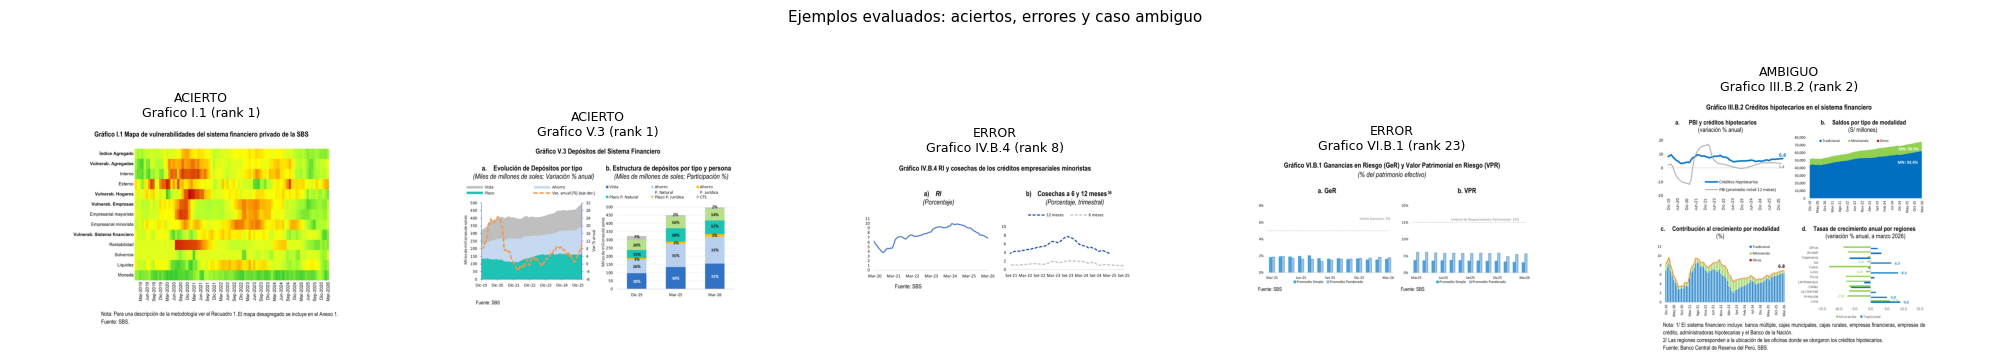

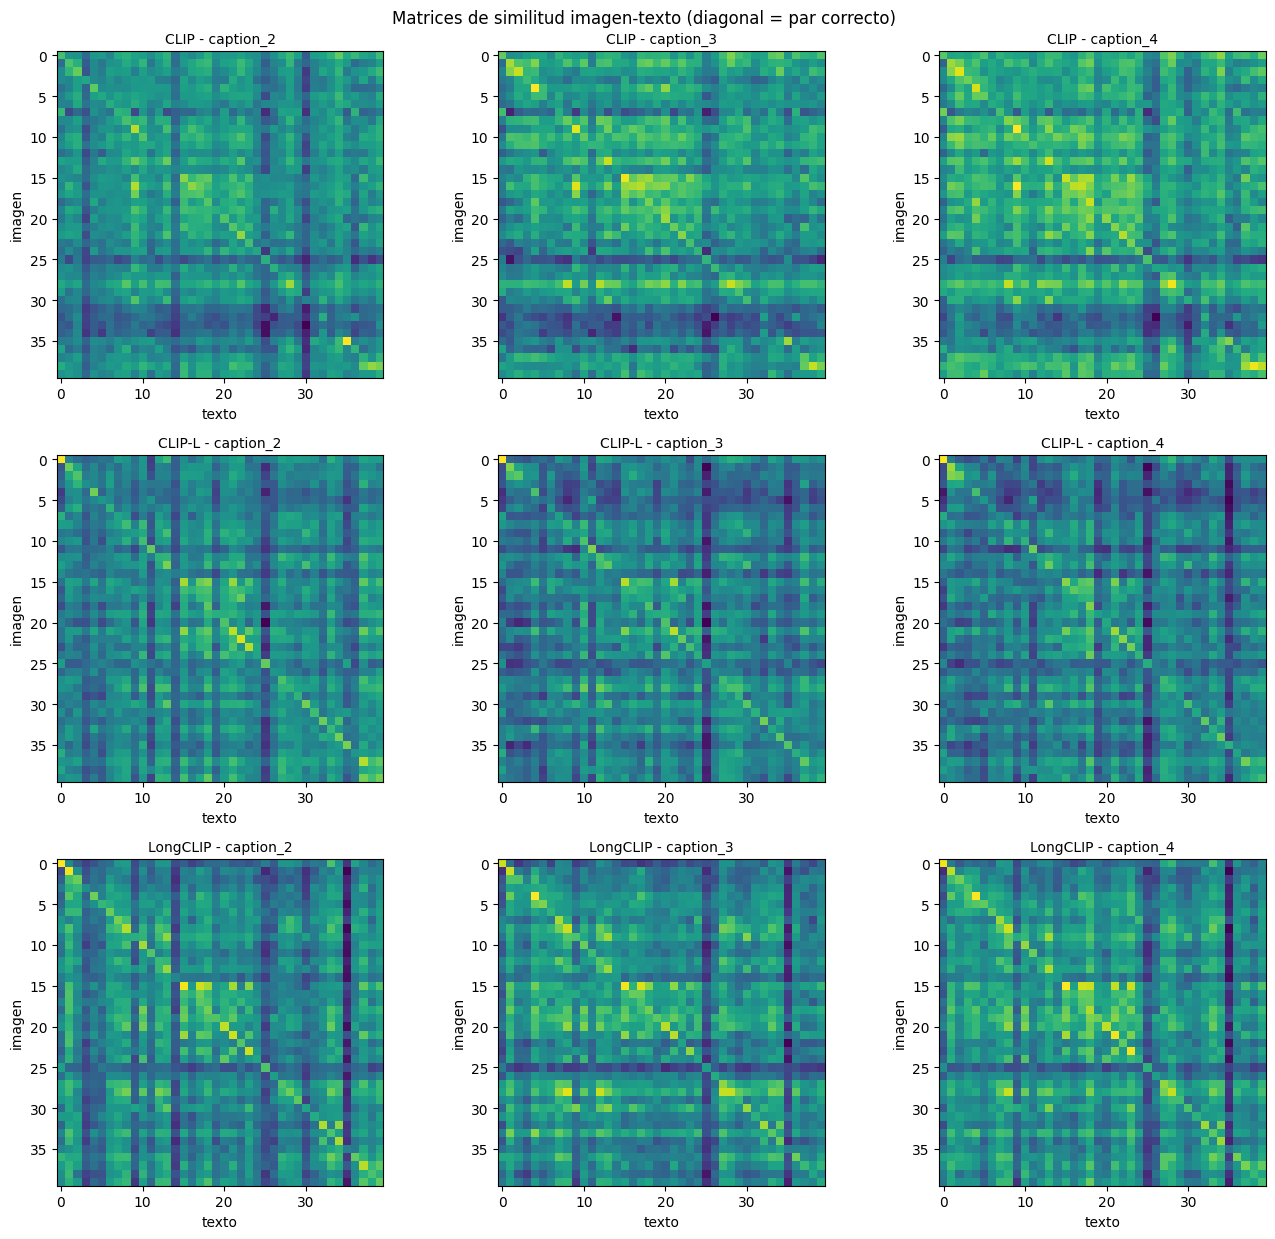

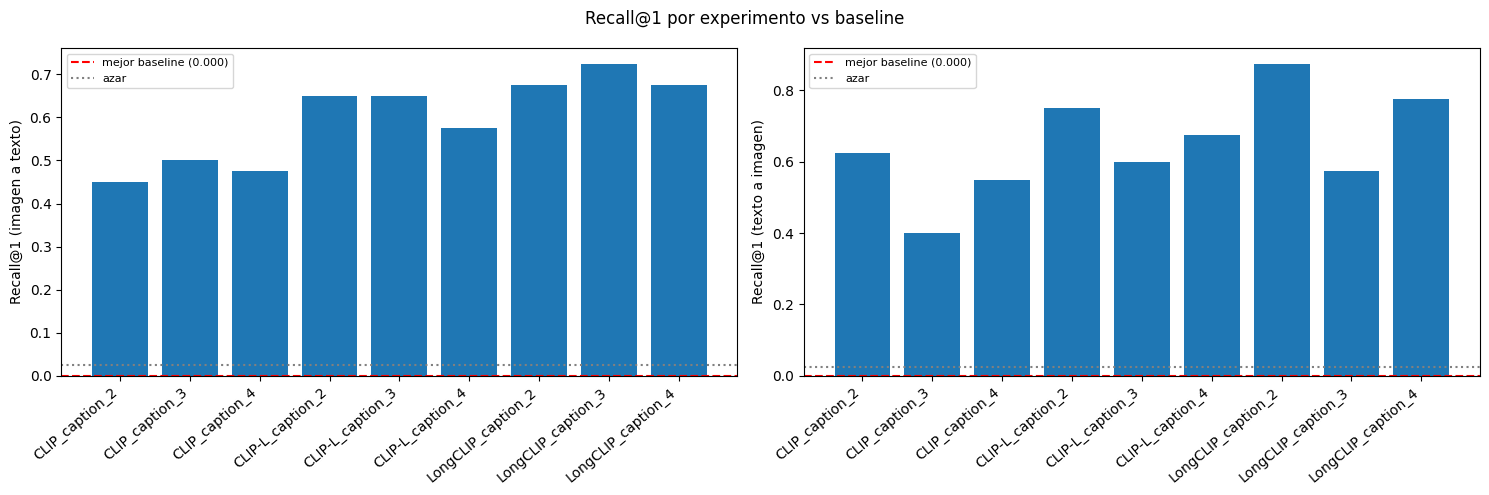

In [9]:
# Imagenes de casos, collage ( y figuras principales
sel = seleccion.merge(manifest[["image_id", "image_path"]], on="image_id")
for _, r in sel.iterrows():
    shutil.copy(r["image_path"], FIG_CASOS / f"{r['tipo_caso']}_{Path(r['image_path']).name}")

fig, axes = plt.subplots(1, len(sel), figsize=(4 * len(sel), 4.2))
for ax, (_, r) in zip(np.atleast_1d(axes), sel.iterrows()):
    ax.imshow(Image.open(r["image_path"]).convert("RGB")); ax.axis("off")
    ax.set_title(f"{r['tipo_caso'].upper()}\nGrafico {r['chart_id']} (rank {int(r[col])})", fontsize=9)
plt.suptitle("Ejemplos evaluados: aciertos, errores y caso ambiguo", fontsize=11)
plt.tight_layout(); plt.savefig(FIGURES / "ejemplos_evaluados.png", dpi=150, bbox_inches="tight"); plt.show()

n_mod = len(MODEL_SPECS)
fig, axes = plt.subplots(n_mod, len(CAPTIONS), figsize=(4.5 * len(CAPTIONS), 4.2 * n_mod))
for i, clave in enumerate(MODEL_SPECS):
    for j, cap in enumerate(CAPTIONS):
        ax = axes[i][j] if n_mod > 1 else axes[j]
        ax.imshow(sims[(clave, cap)].numpy()); ax.set_title(f"{clave} - {cap}", fontsize=10)
        ax.set_xlabel("texto"); ax.set_ylabel("imagen")
plt.suptitle("Matrices de similitud imagen-texto (diagonal = par correcto)")
plt.tight_layout(); plt.savefig(FIGURES / "matrices_similitud.png", dpi=150); plt.show()

sub = metricas[~metricas.experimento.str.contains("baseline")]
base = metricas[metricas.experimento.str.contains("baseline")]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, met, titulo in [(axes[0], "i2t_R@1", "imagen a texto"), (axes[1], "t2i_R@1", "texto a imagen")]:
    ax.bar(sub.experimento, sub[met])
    ax.axhline(base[met].max(), color="red", ls="--", label=f"mejor baseline ({base[met].max():.3f})")
    ax.axhline(1/len(manifest), color="gray", ls=":", label="azar")
    ax.set_ylabel(f"Recall@1 ({titulo})"); ax.tick_params(axis="x", rotation=40)
    for lbl in ax.get_xticklabels(): lbl.set_ha("right")
    ax.legend(fontsize=8)
plt.suptitle("Recall@1 por experimento vs baseline")
plt.tight_layout(); plt.savefig(FIGURES / "comparacion_r1.png", dpi=150); plt.show()

### Pruebas de confiabilidad (Parte 5)

In [10]:
conf_rows = []
for clave in MODEL_SPECS:
    for variante in ["caption_3", "caption_4"]:
        delta = casos[f"rank_{clave}_{variante}"] - casos[f"rank_{clave}_caption_2"]
        cambio = "bajo" if delta.abs().mean() < 2 else ("medio" if delta.abs().mean() < 6 else "alto")
        conf_rows.append({
            "prueba": "A_sensibilidad_prompt", "modelo": clave,
            "entrada_original": "caption_2 (titulo corto)", "variante": variante,
            "delta_rank_promedio": round(float(delta.mean()), 2),
            "casos_que_empeoran": int((delta > 0).sum()),
            "casos_que_mejoran": int((delta < 0).sum()),
            "cambio_observado": cambio,
        })
for clave in MODEL_SPECS:
    real = metricas.query("experimento == @clave + '_caption_2'")["i2t_R@1"].iloc[0]
    bl = metricas.query("experimento == @clave + '_baseline_desplazado'")["i2t_R@1"].iloc[0]
    conf_rows.append({
        "prueba": "C_baseline", "modelo": clave,
        "entrada_original": f"pares reales (R@1={real})", "variante": f"pares desplazados (R@1={bl})",
        "delta_rank_promedio": None, "casos_que_empeoran": None, "casos_que_mejoran": None,
        "cambio_observado": "alto" if real > max(bl, 0.001) * 3 else "medio",
    })
confiabilidad = pd.DataFrame(conf_rows)
confiabilidad.to_csv(RESULTS / "pruebas_confiabilidad.csv", index=False)
confiabilidad

,prueba,modelo,entrada_original,variante,delta_rank_promedio,casos_que_empeoran,casos_que_mejoran,cambio_observado
0,A_sensibilidad_prompt,CLIP,caption_2 (titulo corto),caption_3,-1.68,9.0,13.0,medio
1,A_sensibilidad_prompt,CLIP,caption_2 (titulo corto),caption_4,-0.70,11.0,9.0,medio
2,A_sensibilidad_prompt,CLIP-L,caption_2 (titulo corto),caption_3,-0.85,4.0,13.0,medio
3,A_sensibilidad_prompt,CLIP-L,caption_2 (titulo corto),caption_4,-0.82,11.0,10.0,bajo
4,A_sensibilidad_prompt,LongCLIP,caption_2 (titulo corto),caption_3,-0.45,6.0,8.0,bajo
5,A_sensibilidad_prompt,LongCLIP,caption_2 (titulo corto),caption_4,0.25,10.0,7.0,bajo
6,C_baseline,CLIP,pares reales (R@1=0.45),pares desplazados (R@1=0.0),NaN,NaN,NaN,alto
7,C_baseline,CLIP-L,pares reales (R@1=0.65),pares desplazados (R@1=0.0),NaN,NaN,NaN,alto
8,C_baseline,LongCLIP,pares reales (R@1=0.675),pares desplazados (R@1=0.0),NaN,NaN,NaN,alto


In [11]:
import transformers
meta = {
    "semilla": SEED, "python": sys.version.split()[0], "torch": torch.__version__,
    "transformers": transformers.__version__, "dispositivo": str(DEVICE),
    "modelos": {k: {"checkpoint": v["name"], "max_tokens_texto": v["maxlen"]} for k, v in MODEL_SPECS.items()},
    "captions_evaluados": CAPTIONS, "n_pares": len(manifest),
    "dataset": "SBS IESF Mayo 2026 - 40 graficos extraidos",
}
(RESULTS / "metadata_experimento.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False))
print(json.dumps(meta, indent=2, ensure_ascii=False))

{
  "semilla": 22514,
  "python": "3.11.0rc1",
  "torch": "2.5.1+cu121",
  "transformers": "4.57.6",
  "dispositivo": "cuda",
  "modelos": {
    "CLIP": {
      "checkpoint": "openai/clip-vit-base-patch32",
      "max_tokens_texto": 77
    },
    "CLIP-L": {
      "checkpoint": "openai/clip-vit-large-patch14",
      "max_tokens_texto": 77
    },
    "LongCLIP": {
      "checkpoint": "zer0int/LongCLIP-GmP-ViT-L-14",
      "max_tokens_texto": 248
    }
  },
  "captions_evaluados": [
    "caption_2",
    "caption_3",
    "caption_4"
  ],
  "n_pares": 40,
  "dataset": "SBS IESF Mayo 2026 - 40 graficos extraidos"
}


### Mapa de salidas y lectura de resultados

| Archivo | Parte de la Actividad 5 |
|---|---|
| `results/metricas.csv` | Parte 3 / Entregable 3 (9 experimentos + 3 baselines) |
| `results/auditoria_truncacion.csv` | Partes 2-3 (LongCLIP debe mostrar 0% en caption_3/4) |
| `results/scores_por_caso.csv`, `results/casos_analizados.csv` | Parte 4 / Entregable 4 |
| `results/pruebas_confiabilidad.csv` | Parte 5 |
| `figures/ejemplos_evaluados.png`, `figures/casos/` | Entregable 6 |
| `figures/matrices_similitud.png`, `figures/comparacion_r1.png` | figuras del reporte |
| `results/metadata_experimento.json` | reproducibilidad |

**Interpretacion honesta si LongCLIP mejora sobre CLIP-L en t2i con resumenes**: el texto completo hace las consultas mas distintivas entre si; NO significa que el modelo comprenda los datos numericos (el encoder visual sigue sin leer cifras). Verificacion opcional: perturbar una cifra del caption (4.4% -> 9.4%) no deberia cambiar el score de forma apreciable.

**Los resultados de SigLIP2 de la v2 no se descartan**: siguen en el reporte como comparacion multilingue; esta v3 responde una pregunta distinta (tamano vs contexto) dentro de la familia CLIP.